In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

In [2]:
# import json
# import logging
import os
import math
# import random
# import shutil
# from pathlib import Path
# from itertools import chain
import gc

# from dotenv import load_dotenv
import torch
import numpy as np
import accelerate
from torch.utils.data import DataLoader
import datasets
# from datasets import Dataset, load_dataset, load_from_disk

from lm_experiments_tools import Trainer, TrainerArgs
from lm_experiments_tools.utils import ObjectView

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data.distributed import DistributedSampler

# load_dotenv()
from babilong_utils import TaskDataset, SentenceSampler, NoiseInjectionDataset

from transformers import AutoConfig, AutoTokenizer #, HfArgumentParser  # noqa: E402

from lm_experiments_tools.utils import get_optimizer, get_cls_by_name #, prepare_run  # noqa: E402


In [3]:
if os.environ.get('CUDA_VISIBLE_DEVICES', None) is None:
    os.environ['CUDA_VISIBLE_DEVICES'] = ','.join([str(i) for i in range(torch.cuda.device_count())])

### Load model

In [4]:
args = dict(
    task_dataset = 'qa1_single-supporting-fact',
    # task_dataset = 'qa3_three-supporting-facts',
    noise_dataset = 'pg19',
    noise_dataset_split = None,
    babi_path = '/data/home/admin/rmt/data/tasks_1-20_v1-2/en-10k',
    from_pretrained = 'gpt2',
    model_type = 'decoder',
    memory_cell_cls = 'modeling_rmt.rmt_br:MemoryCell',
    recurrent_wrapper_cls = 'modeling_rmt.rmt_br:RecurrentWrapper',
    model_cls = 'transformers:AutoModelForCausalLM',
    
    max_n_facts = None,
    task_start_pct = 0.0,
    task_end_pct = 1.0,

    segment_size = 128,
    num_mem_tokens = 4,
    max_n_segments = 6,
    sample_size = 768,
    res_mem_count = -1,
    tokenizer = 'gpt2',
    vary_n_segments = False,
    batch_size = 1,
    gradient_accumulation_steps = 1,
    num_training_steps = 10000,
    iters = 5000,
    reset_optimizer = True,
    reset_lr = True,
    reset_iteration = True,
    save_best = True,
    k2 = -1,
    optimizer = 'AdamW',
    weight_decay = 0.01,
    lr = 5e-5,
    lr_scheduler = 'linear',
    num_warmup_steps = 500,
    data_n_workers = 4,
    optimize_metric = 'exact_match',
    optimizer_mode = 'max',
    best_metric_value = 1.0,
    show_valid_examples = 5,
    early_stopping_patience = 10,
    seed = 42,
    clip_crad_norm = 1.0,
    mixed_length_ratio = 0.0,
    segment_alignment = None,
    sep_seg_q = True,
    aggr_type='layer'
)
args = ObjectView(args)

In [5]:
accelerator = accelerate.Accelerator(gradient_accumulation_steps=args.gradient_accumulation_steps)

In [6]:
if not args.from_pretrained:
    tokenizer = AutoTokenizer.from_pretrained(args.tokenizer)
else:
    tokenizer = AutoTokenizer.from_pretrained(args.from_pretrained)

In [7]:
noise_dataset = datasets.load_dataset(args.noise_dataset, args.noise_dataset_split)
noise_dataset_train = noise_dataset['train']
noise_dataset_test = noise_dataset['test']

In [8]:
train_path = os.path.join(args.babi_path, f"{args.task_dataset}_train.txt")
test_path = os.path.join(args.babi_path, f"{args.task_dataset}_test.txt")

task_dataset_train = TaskDataset(train_path, max_n_facts=args.max_n_facts)
task_dataset_test = TaskDataset(test_path, max_n_facts=args.max_n_facts)

In [9]:
# background text
qa_margin = 20          # leave space for questions and answers
if args.vary_n_segments:  # choose sample sizes according to each number of segments up to args.max_n_segments
    # train_sample_size = [int(args.sample_size / i) for i in range(1, args.max_n_segments + 1)]
    train_sample_size = [int(args.segment_size * i) for i in range(1, args.max_n_segments)] + [args.sample_size]
    train_sample_size = [s - qa_margin for s in train_sample_size]
else:
    sample_size = args.sample_size - qa_margin
    train_sample_size = args.sample_size - qa_margin
test_sample_size = args.sample_size - qa_margin
max_sentence_len = None
if (args.task_start_pct is not None) and (args.task_end_pct is not None):
    # do not sample sentences longer than task position range * 0.5
    max_sentence_len = int((args.task_end_pct - args.task_start_pct) * 0.5 * args.sample_size)
    
noise_sampler_train = SentenceSampler(noise_dataset_train, tokenizer=tokenizer, max_sentence_len=max_sentence_len, shuffle=True, random_seed=None)
noise_sampler_test = SentenceSampler(noise_dataset_test, tokenizer=tokenizer, max_sentence_len=max_sentence_len, shuffle=True, random_seed=42)

In [10]:
train_dataset = NoiseInjectionDataset(
    task_dataset=task_dataset_train,
    noise_sampler=noise_sampler_train,
    tokenizer=tokenizer,
    sample_size=train_sample_size,
    mixed_length_ratio=args.mixed_length_ratio,
    task_start_pct=args.task_start_pct,
    task_end_pct=args.task_end_pct
)

test_dataset = NoiseInjectionDataset(
    task_dataset=task_dataset_test,
    noise_sampler=noise_sampler_test,
    tokenizer=tokenizer,
    sample_size=test_sample_size,
    mixed_length_ratio=args.mixed_length_ratio,
    task_start_pct=args.task_start_pct,
    task_end_pct=args.task_end_pct
)

In [11]:
id_pad_value = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
gen_token = tokenizer.encode('GEN')[0]
eos_token = tokenizer.eos_token_id

def collate_fn(batch):
    targets = [torch.tensor(b['target_tokens']) for b in batch]
    if args.sep_seg_q:
        input_ids = [torch.tensor(b['input_tokens'] + ((-len(b['input_tokens'])) % args.segment_size) * [id_pad_value] +
                                    b['question_tokens'] + [gen_token] + b['target_tokens'] + [eos_token]) for b in batch]
        gen_inputs = [torch.tensor(b['input_tokens'] + ((-len(b['input_tokens'])) % args.segment_size) * [id_pad_value] +
                                    b['question_tokens'] + [gen_token]) for b in batch]
    else:
        input_ids = [torch.tensor(b['input_tokens'] + b['question_tokens'] + [gen_token] + b['target_tokens'] + [eos_token]) for b in batch]
        gen_inputs = [torch.tensor(b['input_tokens'] + b['question_tokens'] + [gen_token]) for b in batch]

    attention_mask = [torch.ones_like(b, dtype=int) for b in input_ids]
    labels_mask = [torch.zeros_like(b, dtype=bool) for b in input_ids]
    for m, t in zip(labels_mask, targets):
        m[-len(t) - 2:] = True

    input_ids = pad_sequence(input_ids, padding_value=id_pad_value, batch_first=True)
    gen_inputs = pad_sequence(gen_inputs, padding_value=id_pad_value, batch_first=True)
    attention_mask = pad_sequence(attention_mask, padding_value=0, batch_first=True)
    labels_mask = pad_sequence(labels_mask, padding_value=0, batch_first=True)

    collated = {}
    collated['input_ids'] = collated['labels'] = input_ids
    collated['input_ids_generate'] = gen_inputs
    collated['labels_mask'] = labels_mask
    collated['attention_mask'] = attention_mask.bool()
    collated['attention_mask_generate'] = (gen_inputs != id_pad_value).bool()
    collated['target_text'] = [b['answer'] for b in batch]
    return collated

In [12]:
kwargs = {'pin_memory': True, 'num_workers': args.data_n_workers, 'collate_fn': collate_fn}
per_worker_batch_size = args.batch_size * args.gradient_accumulation_steps
train_sampler = DistributedSampler(train_dataset, rank=accelerator.process_index,
                                    num_replicas=accelerator.num_processes, shuffle=True, drop_last=True,
                                    seed=args.seed)
test_sampler = DistributedSampler(test_dataset, rank=accelerator.process_index,
                                    num_replicas=accelerator.num_processes, drop_last=False, shuffle=False)
train_dataloader = DataLoader(batch_size=per_worker_batch_size, dataset=train_dataset, sampler=train_sampler,
                                **kwargs)
test_dataloader = DataLoader(batch_size=per_worker_batch_size, dataset=test_dataset, sampler=test_sampler, **kwargs)

/data/home/admin/miniforge3/envs/rmt/lib/python3.13/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained('gpt2')
config.num_mem_tokens = args.num_mem_tokens

In [14]:
model_cls = get_cls_by_name(args.model_cls)
model = model_cls.from_pretrained(args.from_pretrained, use_safetensors=False)

memory_cell_cls = get_cls_by_name(args.memory_cell_cls)
recurrent_wrapper_cls = get_cls_by_name(args.recurrent_wrapper_cls)

cell = memory_cell_cls(model, args.num_mem_tokens, args.res_mem_count, aggr_type=args.aggr_type)

max_n_segments = args.max_n_segments
if max_n_segments in {-1, None}:
    max_n_segments = np.ceil(args.sample_size / args.segment_size)
model = recurrent_wrapper_cls(
    cell, 
    segment_size=args.segment_size,
    max_n_segments=max_n_segments, 
    segment_alignment=args.segment_alignment,
    k2=args.k2,
)

In [15]:
optimizer_cls = get_optimizer(args.optimizer)
optimizer = optimizer_cls(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

In [16]:
def keep_for_metrics_fn(batch, output):
    # select data from batch and model output that would be used to compute metrics
    data = {}
    data['labels'] = batch['labels']
    data['loss'] = output['loss']
    data['target_text'] = batch['target_text']
    if 'logits' in output:
        data['predictions'] = torch.argmax(output['logits'].detach(), dim=-1)
        data['predicted_labels'] = [p[m] for p, m in zip(data['predictions'], batch['labels_mask'])]
    if 'generation_outputs' in output:
        data['generation_outputs'] = output['generation_outputs']
    return data

In [17]:
model, optimizer = accelerator.prepare(model, optimizer)

In [18]:
def metrics_fn(data):
    # compute metrics based on stored labels, predictions, ...
    metrics = {}
    if 'generation_outputs' in data:
        generation_outputs = tokenizer.batch_decode([d for d in data['generation_outputs']], add_special_tokens=False)
        for i, o in enumerate(generation_outputs):
            if '<|endoftext|>' in o:
                # print(f"gt: {data['target_text'][i]}, generated {o}")
                generation_outputs[i] = o.split('<|endoftext|>')[1].strip()

        metrics['exact_match'] = np.mean([text == pred for text, pred in zip (data['target_text'], generation_outputs)])

    elif 'predictions' in data:
        y, p = data['labels'], data['predictions']
        predicted_labels = tokenizer.batch_decode(data['predicted_labels'], add_special_tokens=False)
        for i, l in enumerate(predicted_labels):
            if '<|endoftext|>' in l:
                eos_ind = predicted_labels[i].index('<|endoftext|>')
                predicted_labels[i] = predicted_labels[i][:eos_ind]
                
        metrics['exact_match'] = np.mean([text == pred for text, pred in zip (data['target_text'], predicted_labels)])
    try:
        perplexity = math.exp(data["loss"].mean())
    except OverflowError:
        perplexity = float("inf")
    metrics["perplexity"] = perplexity

    return metrics

In [19]:
batch_metrics_fn = lambda _, y: {key: y[key] for key in y.keys() if (('loss' in key) or ('!log' in key))}

In [20]:
CPT_PATH = "/home/admin/rmt/runs/qa1_single-supporting-fact/gpt2/rmt-br/linear_adamw_wd1e-03_6x128_mem4_resmem-1_bs24_bptt--1_from_cpt_0-6_teacher-forcing/run_sep_q_fix/model_best/model.pth"
checkpoint = torch.load(CPT_PATH, map_location='cpu', weights_only=False)
missing_k, unexpected_k = accelerator.unwrap_model(model).load_state_dict(checkpoint.state_dict(), strict=False)

[2025-02-27 04:32:00,300] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/data/home/admin/miniforge3/envs/rmt/bin/../lib/gcc/x86_64-conda-linux-gnu/13.3.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


In [21]:
torch.cuda.empty_cache()
gc.collect()
model.to('cuda:0')
# model.to('cpu')

RecurrentWrapper(
  (memory_cell): MemoryCell(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x MemoryLayerWrapper(
            (layer): GPT2Block(
              (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (attn): GPT2Attention(
                (c_attn): Conv1D(nf=2304, nx=768)
                (c_proj): Conv1D(nf=768, nx=768)
                (attn_dropout): Dropout(p=0.1, inplace=False)
                (resid_dropout): Dropout(p=0.1, inplace=False)
              )
              (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
              (mlp): GPT2MLP(
                (c_fc): Conv1D(nf=3072, nx=768)
                (c_proj): Conv1D(nf=768, nx=3072)
                (act): NewGELUActivation()
                (dropout): Dropout(p=0.1, inplace=False)
              )

In [22]:
with torch.no_grad():
    for batch in train_dataloader:
        tokens = tokenizer.batch_decode(batch['input_ids'])
        # input_ids = batch['input_ids'].to('cpu')
        # labels = batch['labels'].to('cpu')
        # labels_mask = batch['labels_mask'].to('cpu')
        # attention_mask = batch['attention_mask'].to('cpu')
        input_ids = batch['input_ids'].to('cuda:0')
        labels = batch['labels'].to('cuda:0')
        labels_mask = batch['labels_mask'].to('cuda:0')
        attention_mask = batch['attention_mask'].to('cuda:0')
        break

/data/home/admin/miniforge3/envs/rmt/lib/python3.13/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...


To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | fal

In [9]:
# model.to('cpu')
model.to('cuda:0')
out = model(
    input_ids=input_ids,
    labels=labels,
    labels_mask=labels_mask,
    attention_mask=attention_mask,
    output_hidden_states=True
)

out['loss'].backward()

NameError: name 'model' is not defined

In [49]:
model.memory_cell.layers[-1].past_memory_states[-1].norm(p=2)

tensor(76390.0703, grad_fn=<LinalgVectorNormBackward0>)

In [48]:
out['hidden_states_6'][-1].norm(p=2)

tensor(889.1476, grad_fn=<LinalgVectorNormBackward0>)

In [24]:
total_grad = 0
num_params = 0

lines = []

for name, param in model.named_parameters():
    if param.grad is not None:
        mgrad = param.grad.abs().mean()
        # if mgrad > 5:
        lines.append(f"{name[30:]}: mean grad={float(mgrad):.5f}, mean weight={float(param.data.mean().item()):.5f}, std={float(param.data.std().item()):.5f}")
        total_grad += mgrad
        num_params += 1

avg_grad = total_grad / num_params if num_params > 0 else 0

lines.sort(key=lambda x: '' if 'memory' in x else (' ' if 'aggregator' in x else x))
print('\n'.join(lines))

print("Average Gradient of Model Parameters:", avg_grad.item() if num_params > 0 else "No gradients")

h.0.memory: mean grad=0.06353, mean weight=-0.00001, std=0.14375
h.1.memory: mean grad=0.03881, mean weight=0.00102, std=0.14389
h.2.memory: mean grad=0.02627, mean weight=-0.00133, std=0.14621
h.3.memory: mean grad=0.02180, mean weight=-0.00200, std=0.14375
h.4.memory: mean grad=0.01842, mean weight=-0.00107, std=0.14492
h.5.memory: mean grad=0.03075, mean weight=0.00108, std=0.14487
h.6.memory: mean grad=0.01000, mean weight=0.00322, std=0.13908
h.7.memory: mean grad=0.02965, mean weight=-0.00046, std=0.14595
h.8.memory: mean grad=0.04361, mean weight=0.00045, std=0.14339
h.9.memory: mean grad=0.01919, mean weight=-0.00211, std=0.14517
h.10.memory: mean grad=0.01271, mean weight=-0.00238, std=0.14106
h.11.memory: mean grad=0.00089, mean weight=-0.00126, std=0.14273
h.0.aggregator.attention.in_proj_weight: mean grad=0.00259, mean weight=0.00000, std=0.02552
h.0.aggregator.attention.in_proj_bias: mean grad=0.00064, mean weight=-0.00000, std=0.00011
h.0.aggregator.attention.out_proj.wei

In [23]:
# %%prun

with torch.no_grad():
    out = model(
        input_ids=input_ids,
        labels=labels,
        labels_mask=labels_mask,
        attention_mask=attention_mask,
        output_attentions=True
    )

    # generate_kwargs={"pad_token_id": id_pad_value, "max_new_tokens":10}
    # out_gen = model.generate(input_ids=input_ids, attention_mask=attention_mask, **generate_kwargs)


# del input_ids
# del labels
# del labels_mask
# del attention_mask

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


ValueError: not enough values to unpack (expected 2, got 1)

In [36]:
out.keys()

odict_keys(['loss', 'logits', 'logits_0', 'logits_1', 'logits_2', 'logits_3', 'logits_4', 'logits_5', 'logits_6'])

In [33]:
out['attentions_6'][1].shape

torch.Size([1, 12, 41, 41])

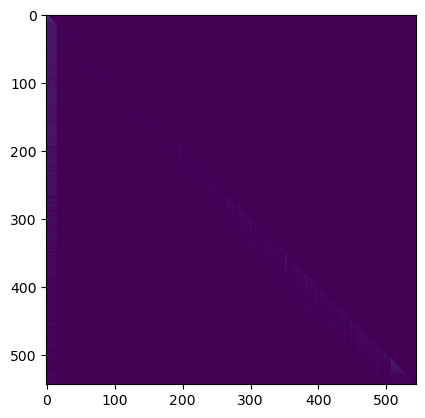

In [25]:
import matplotlib.pyplot as plt
plt.imshow(out['attentions_5'][0][0, 0, :, :].cpu())

In [27]:
out

RMTOutput(loss=tensor(9.6748, device='cuda:0'), logits=tensor([[[ -35.5576,  -35.0944,  -39.3168,  ...,  -42.2403,  -42.7598,
           -35.7094],
         [-107.2378, -105.9470, -110.4605,  ..., -107.2561, -111.5198,
          -105.1667],
         [ -56.6069,  -57.7267,  -61.9336,  ...,  -62.9325,  -65.2220,
           -57.4219],
         ...,
         [ -77.0701,  -75.0284,  -77.5937,  ...,  -86.7593,  -85.7690,
           -76.4081],
         [ -77.0686,  -75.0242,  -77.5840,  ...,  -86.7580,  -85.7670,
           -76.4059],
         [ -77.0852,  -75.0469,  -77.5983,  ...,  -86.7779,  -85.7873,
           -76.4146]],

        [[ -35.5285,  -35.2354,  -38.4663,  ...,  -42.5273,  -41.3286,
           -35.7246],
         [ -52.3914,  -52.7442,  -58.3818,  ...,  -60.3900,  -61.4330,
           -53.7836],
         [ -68.5701,  -67.9622,  -72.9510,  ...,  -74.3398,  -75.4585,
           -67.9956],
         ...,
         [ -84.4709,  -86.6265,  -87.0430,  ...,  -95.3642,  -93.1223,
       

In [29]:
predictions = torch.argmax(out['logits'].detach(), dim=-1)
predicted_labels = [p[m] for p, m in zip(predictions, batch['labels_mask'])]

In [31]:
tokenizer.batch_decode(predicted_labels)

['bathroom<|endoftext|><|endoftext|>', 'bathroom<|endoftext|><|endoftext|>']

In [41]:
tokens = tokenizer.batch_decode(batch['input_ids'])
print(tokens[0])

“_Je suis
touché!_” he exclaims; the weapon falls; “honour” has been satisfied.From forts and other positions around the city firing increases in
degree; it is continuous by day and throughout the night.Within,
there are large bodies of troops in motion to the sounds of drum and
bugle; orders issued that all gates of the fortifications shall be
closed alike to egress and ingress, these incidents being precursors of
another attempt against the enemy.Daniel went to the kitchen.Daniel moved to the bathroom.Long before daybreak on December 21
the Rue Lafayette was crowded by troops and ambulance establishments
making their way to the Porte de Pantin.Soon thereafter a combined
force,[304] comprising this and other portions, took up position on
the open field, triangular in form, at the angles of which stand
respectively Aubervilliers, Le Bourget, and Drancy.Sandra went to the bedroom.On the left of
the French position the combat immediately became terrific in its
violence, the interchange o

In [42]:
print("".join(tokenizer.batch_decode(out_gen[0])))

.Sandra journeyed to the bedroom.So
heavy was the volume of fire on that position that during three days
of its continuance it was estimated that 7,000 missiles--all of large
size--fell upon it.Mary picked up the milk.Manfully for a time did the defenders stand their
ground; very great their losses in killed and wounded when at last they
were forced to abandon their forts on the north-eastern side, their
wounded serving to still further crowd the overcrowded ambulances.The
ultimate issue of the siege, never very doubtful to us foreigners,
had now become less so than before.Men asked each other, ��How is it
that 600,000 Frenchmen permitted themselves to be blockaded by 200,000
Germans?�� The mystery seemed to be solved by a writer[306] of that day,
somewhat according to this manner: ��It is confessed that the Governor
(Trochu) has shown unfortunate hesitations; but to do good work the
tools must be good, and in these respects he is deficient.To fight
the Prussians we should have old sol

In [40]:
batch['target_text']

['hallway', 'garden']

In [39]:
tokenizer.batch_decode([d for d in out], add_special_tokens=False)

['<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftex

In [ ]:
generation_outputs = tokenizer.batch_decode([d for d in out], add_special_tokens=False)
for i, o in enumerate(generation_outputs):
    if '<|endoftext|>' in o:
        # print(f"gt: {data['target_text'][i]}, generated {o}")
        generation_outputs[i] = o.split('<|endoftext|>')[0].strip()
        print(generation_outputs[i])

exact_match = np.mean([text == pred for text, pred in zip (batch['target_text'], generation_outputs)])




the
tone of remonstrance he thought he detected in the old woman's voice.'An' it's no afore my fire but intil't, the duds o' yer dochter's brat
sall gang, ay!gin ye tak na them out o' here.to lay hersel' down in a decent man's bed, an'
never "wi' yer leave?"'He even got so far as to begin tossing the
child's clothing together in a heap, when the old woman, snatching a
brand from the hearth, struck him across the hand with the red hot
end, making him desist with a scream of pain.He glared at her for an
instant as if about to rush on her, then wavered and turned round as
if about to call for help.Gin ye gang yaupin'
an' skirlin' out there, ye'se raise a din wull do far mair scaith to
yersel', nor it can til hiz.An' gin ye aince raise 't, ye'll ne'er
can lay't again!sae keep ye a calm sough, an' let me hae my say.'Sandra moved to the bedroom.It wasna muckle,' she continued, ''at I kenned o' you an' Tibbie's
on-gaein's, whan I spak to ye first, an' I spak ye fair, an' ye ken
what cam o' '

In [34]:
generation_outputs

['', '']

In [33]:
exact_match

np.float64(0.0)

In [23]:
del input_ids
del labels
del labels_mask
del attention_mask
del batch

NameError: name 'input_ids' is not defined

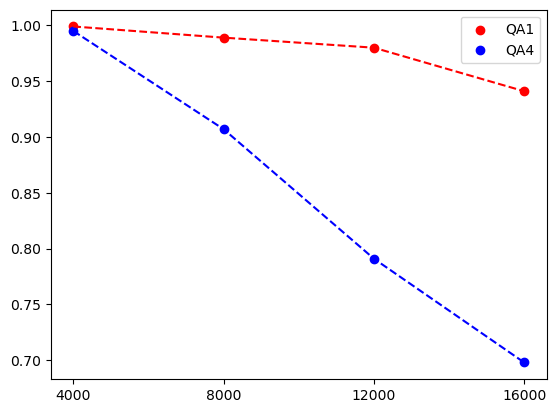

In [28]:
from matplotlib import pyplot as plt
%matplotlib inline

x = [4000, 8000, 12000, 16000]
y1 = [0.999, 0.989, 0.98, 0.941]
y2 = [0.995, 0.907, 0.791, 0.698]

plt.plot(x, y1, linestyle='--', color='red')
plt.scatter(x, y1, color='red', label='QA1')

plt.plot(x, y2, linestyle='--', color='blue')
plt.scatter(x, y2, color='blue', label='QA4')

plt.xticks(x)
plt.legend()
plt.show()

In [1]:
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib import gridspec
import numpy as np

def plot_mem_attn(layer_attns):
    n_layers = len(layer_attns)
    n_batches = layer_attns[0].shape[0]
    n_mem_tokens = layer_attns[0].shape[1]
    layer_widths = [i + 1 for i in range(n_layers)]

    fig = plt.figure(figsize=(4 * sum(layer_widths), 4 * n_batches), layout="constrained")
    gs = gridspec.GridSpec(n_batches, n_layers, width_ratios=layer_widths, )

    for i in range(n_batches):
        for j in range(n_layers):
            ax = fig.add_subplot(gs[i * n_layers + j])
            ax.imshow(layer_attns[j][i, ...].cpu(), cmap='Reds')
            ax.set_title(f'batch {i}, layer {j}')
            ax.tick_params(axis='both', which='major', labelsize=8)
            ax.tick_params(axis='x', which='both', top=True, bottom=False, labeltop=True, labelbottom=False)
            ax.set_xticks(np.arange(0, n_mem_tokens * (j + 1), 1))
            ax.set_yticks(np.arange(0, n_mem_tokens, 1))

plot_mem_attn(memory_attn_out)

NameError: name 'memory_attn_out' is not defined

In [42]:
out[0]['attentions_0'][0].shape

torch.Size([6, 12, 544, 544])

In [45]:
out[0]['attentions_0'][1].shape

torch.Size([6, 12, 544, 544])

In [50]:
out[0].keys()

odict_keys(['loss', 'logits', 'hidden_states', 'logits_0', 'hidden_states_0', 'attentions_0', 'logits_1', 'hidden_states_1', 'attentions_1'])

/data/home/admin/miniforge3/envs/resrmt/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/data/home/admin/miniforge3/envs/resrmt/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


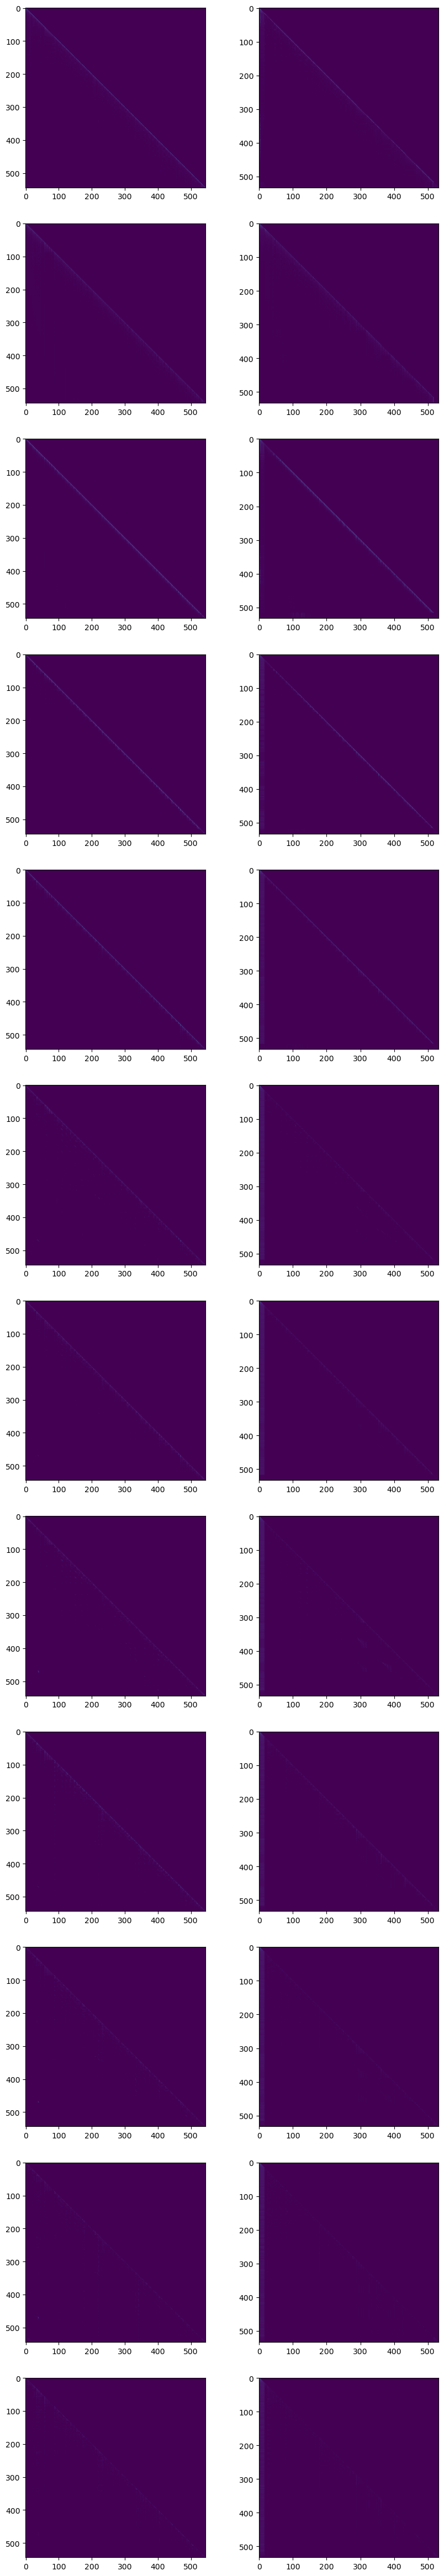

In [56]:
# def plot_mem_attn(layer_attns):
#     n_layers = len(layer_attns)
#     n_batches = layer_attns[0].shape[0]
#     n_mem_tokens = layer_attns[0].shape[1]
#     layer_widths = [i + 1 for i in range(n_layers)]

#     fig = plt.figure(figsize=(4 * sum(layer_widths), 4 * n_batches), layout="constrained")
#     gs = gridspec.GridSpec(n_batches, n_layers, width_ratios=layer_widths, )

#     for i in range(n_batches):
#         for j in range(n_layers):
#             ax = fig.add_subplot(gs[i * n_layers + j])
#             ax.imshow(layer_attns[j][i, ...].cpu(), cmap='Reds')
#             ax.set_title(f'batch {i}, layer {j}')
#             ax.tick_params(axis='both', which='major', labelsize=8)
#             ax.tick_params(axis='x', which='both', top=True, bottom=False, labeltop=True, labelbottom=False)
#             ax.set_xticks(np.arange(0, n_mem_tokens * (j + 1), 1))
#             ax.set_yticks(np.arange(0, n_mem_tokens, 1))


def plot_attentions(out, n_segments, tokens=None, batch_index=0):
    n_layers = 12
    fig = plt.figure(figsize=(10, 60), layout="constrained")
    gs = gridspec.GridSpec(n_layers, n_segments)

    for i in range(n_layers):
        for j in range(n_segments):
            ax = fig.add_subplot(gs[j + i * n_segments])
            ax.imshow(out[0][f'attentions_{j}'][i][batch_index, ...].mean(axis=0).cpu().numpy())


plot_attentions(out, 2)
            

In [27]:
torch.cuda.empty_cache()

with torch.no_grad():
    for batch in train_dataloader:
        print(batch.keys())
        tokens = []
        for j in range(6):
            tokens.append(model.segment(input_ids=batch['input_ids']))
            # tokens.append(tokenizer.convert_ids_to_tokens(t_id).replace('▁', '') for t_id in batch['input_ids'][j].tolist())
        # tokens = [[tokenizer.convert_ids_to_tokens(t_id).replace('▁', '') for t_id in batch['input_ids'][j].tolist() for j in range(6)]]
        break

/data/home/admin/miniforge3/envs/resrmt/lib/python3.9/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

dict_keys(['input_ids', 'labels', 'input_ids_generate', 'labels_mask', 'attention_mask', 'attention_mask_generate', 'target_text'])


In [ ]:
print(tokenizer.batch_decode(tokens[0][1]['input_ids']))

   And some had marked the D.A.Q.M.G.Approaching Railhead in the dusk, and he
      (Who, as a fact, was simply on the spree)
    Had gone, of course, to view the Promised Land.A land of quietude and no grenades,
  Soft beds for officers, fair barns for Tommies,
    And rich estaminets and gracious maids,
      And half-an-hour from Abbeville by the train
      A land of rivulets and golden grain
      (Where it would be impossible to train
    And even difficult to have parades)!Then it appeared the groom of General Harrison
    Had news denied to ordinary men,
  How the Brigade was going home to garrison
    A restful corner of the Lincoln fen;
      But weeks have passed and we are as we were;
      And possibly, when Peace is in the air
      And these dear myths have died of sheer despair,
    They may come true--but not, I think, till then.*       *       *       *       *

FELINE AMENITIES."Cats' Happy Holiday Home--Wired garden, Home comforts,
    References"--_Church Family Ne

In [34]:
print(' '.join([t for t in tokens[5]]))

29 th Ġand Ġ30 th , Ġ18 64 ; ĠHatch ie 's Ċ Run , ĠOct . John Ġjourney ed Ġto Ġthe Ġgarden . 27 th Ġand Ġ28 th , Ġ18 64 ; Ġheavy Ġskirm ish Ġon Ġthe ĠBermuda ĠFront , Ġin Ċ Dec . 18 64 ; ĠFar ra 's ĠIsland Ġat ĠDutch ĠGap ĠCanal , ĠJan . 25 th , Ġ1865 ; Ġand Ċ capt ure Ġof ĠRichmond , ĠApril Ġ3 d , Ġ1865 . [ 2 ] Ċ Ċ FIR ST ĠL IE UT EN ANT ĠJ AMES ĠT . ĠH AY MAN Ġof ĠCo . It Ġis Ġknown Ġin Ġthe Ġhistory Ġof Ġthis Ġwar Ġthat Ġhe Ġwas Ġassociated Ċ with Ġthe Ġ4 th ĠN . Y . Heavy ĠArt illery , Ġin Ġwhich Ġhe Ġhad Ġfirst Ġenlisted Ġas Ċ a ĠPR IV ATE . He Ġreceived Ġthe Ġappointment Ġof ĠFIRST Ċ L IE UT EN ANT Ġof Ġthis ĠReg t . May Ġ15 th , Ġ18 64 , Ġand Ġwas Ġassigned Ġto ĠCo . In Ġthe Ġbattle Ġof Ġthe ĠMine Ġbefore ĠPetersburg , ĠJuly Ġ30 th , Ġ18 64 , Ġhe Ċ was Ġkilled Ġby Ġa Ġball Ġwhich Ġpenetrated Ġhis Ġskull . [ 2 ] ĠFor Ġhistory Ġof Ġ1 st ĠLie ut . O ' B RI EN , Ġsee Ċ Ġ Ġ Ġ Ġ Ġ Ġ Ġ Ġ Ġ Ġhistory Ġof ĠCapt . C . Ċ Ċ In Ġthe Ġabsence Ġof Ġany Ġparticulars Ġof Ġhis Ġmilitary Ġhistory ,

In [32]:
tokens[5]

<generator object <genexpr> at 0x7fc87cf305f0>

In [66]:
out['attentions_0'][0].shape

torch.Size([6, 12, 544, 544])

In [67]:
def plot_attention_weights(attentions, tokens, layer, y_tokens=None, p_attentions=None, filename='att.png', save=False):
    # attentions n_layers x n_heads x len x len
    fig = plt.figure(figsize=(30, 30))
    if y_tokens is None:
        y_tokens = tokens
        fig = plt.figure(figsize=(30, 90))

    attention = attentions[layer]
    if p_attentions:
        p_attention = p_attentions[layer]

    for head in range(attention.shape[0]):
        ax = fig.add_subplot(6, 2, head+1)

        # plot the attention weights
        if p_attentions:
            att = np.concatenate([np.expand_dims(p_attention[head], axis=0), attention[head]], axis=0)
            ax.matshow(att[:len(y_tokens)+1,:len(tokens)], cmap='Reds')
        else:
            ax.matshow(attention[head][:len(y_tokens),:len(tokens)], cmap='Reds')

        fontdict = {'fontsize': 10}

        ax.set_xticks(range(len(tokens)))
        if p_attentions:
            ax.set_yticks(range(len(y_tokens) + 1))
            ax.set_yticklabels(['[P]'] + y_tokens, fontdict)
        else:
            ax.set_yticks(range(len(y_tokens)))
            ax.set_yticklabels(y_tokens, fontdict)

        ax.set_xticklabels(tokens,fontdict=fontdict, rotation=90)

        ax.set_xlabel('Head {}'.format(head+1), fontdict)

    plt.tight_layout()
    if save:
        plt.savefig(filename)
    plt.show()

In [ ]:
for layer in range(len(out['encoder_attentions'])):
    print(f'layer: {layer}')
    if isinstance(out['encoder_attentions'][0], tuple):
        attentions = [layer_atts[0].detach().squeeze().numpy() if layer_atts[0] is not None else None for layer_atts in outputs['encoder_attentions']]
        cd_attentions = [layer_atts[1].detach().squeeze().numpy() for layer_atts in outputs['encoder_attentions']]
        p_attentions = [layer_atts[2].detach().squeeze().numpy() for layer_atts in outputs['encoder_attentions']]
    else:
        p_attentions = None
        attentions = [layer_atts.detach().squeeze().numpy() for layer_atts in outputs['encoder_attentions']]
    if attentions[0] is not None:
        # has regular attention heads
        print(f'att_heads:')
        plot_attention_weights(attentions, tokens=tokens, layer=layer, y_tokens=None, p_attentions=None)
    if p_attentions:
        print(f'cdq att heads:')
        plot_attention_weights(cd_attentions, tokens=tokens, layer=layer, y_tokens=None, p_attentions=p_attentions)